In [ ]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
import kagglehub
path = kagglehub.dataset_download("shyambhu/hands-and-palm-images-dataset")

100%|██████████| 634M/634M [00:07<00:00, 84.9MB/s]

Extracting files...


In [ ]:
print(path)

/root/.cache/kagglehub/datasets/shyambhu/hands-and-palm-images-dataset/versions/2


In [ ]:
print("Dataset path:", path)
print(os.listdir(path))

Dataset path: /kaggle/input/hands-and-palm-images-dataset
['HandInfo.csv', 'Hands']


In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/shyambhu/hands-and-palm-images-dataset/versions/2/HandInfo.csv


In [ ]:
import pandas as pd

csv_path = "/root/.cache/kagglehub/datasets/shyambhu/hands-and-palm-images-dataset/versions/2/HandInfo.csv"

df = pd.read_csv(csv_path)
df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [ ]:
source_img_dir = "/root/.cache/kagglehub/datasets/shyambhu/hands-and-palm-images-dataset/versions/2/Hands/Hands"

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
skinColor,0
accessories,0
nailPolish,0
aspectOfHand,0
imageName,0
irregularities,0


In [ ]:
df["aspectOfHand"].value_counts()

,count
aspectOfHand,
dorsal right,2892
palmar right,2813
dorsal left,2788
palmar left,2583


In [ ]:
palms_df = df[df["aspectOfHand"].str.contains("palmar", case=False, na=False)]
palms_df

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
30,0,27,male,fair,1,0,palmar left,Hand_0000038.jpg,0
31,0,27,male,fair,1,0,palmar left,Hand_0000039.jpg,0
32,0,27,male,fair,1,0,palmar left,Hand_0000040.jpg,0
33,0,27,male,fair,1,0,palmar left,Hand_0000041.jpg,0
34,0,27,male,fair,1,0,palmar left,Hand_0000042.jpg,0
...,...,...,...,...,...,...,...,...,...
11071,1589,22,female,fair,0,0,palmar left,Hand_0011740.jpg,0
11072,1589,22,female,fair,0,0,palmar left,Hand_0011741.jpg,0
11073,1589,22,female,fair,0,0,palmar left,Hand_0011742.jpg,0
11074,1589,22,female,fair,0,0,palmar left,Hand_0011743.jpg,0


In [ ]:
print("Total Palmar Images:", len(palms_df))

Total Palmar Images: 5396


In [ ]:
#Training and Temporary Sets (70% / 30%)
train_df, temp_df = train_test_split(
    palms_df,
    test_size=0.30,
    random_state=42
)

In [ ]:
#Validation and Test (15% / 15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

In [ ]:
print("Training Images:", len(train_df))
print("Validation Images:", len(val_df))
print("Testing Images:", len(test_df))

Training Images: 3777
Validation Images: 809
Testing Images: 810


In [ ]:
source_img_dir = "./Hands"
base_dest_dir = "./split_palm_dataset"

In [ ]:
for folder in ["train", "val", "test"]:
    os.makedirs(os.path.join(base_dest_dir, folder), exist_ok=True)

In [ ]:
source_img_dir = "/root/.cache/kagglehub/datasets/shyambhu/hands-and-palm-images-dataset/versions/2/Hands/Hands"

In [ ]:
#Copy Training Images
copied = 0

for _, row in train_df.iterrows():
    img_name = row["imageName"]

    src = os.path.join(source_img_dir, img_name)
    dst = os.path.join(base_dest_dir, "train", img_name)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        copied += 1

print("Training images copied:", copied)

Training images copied: 3777


In [ ]:
#Copy Validation Images
copied = 0

for _, row in val_df.iterrows():
    img_name = row["imageName"]

    src = os.path.join(source_img_dir, img_name)
    dst = os.path.join(base_dest_dir, "val", img_name)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        copied += 1

print("Validation images copied:", copied)

Validation images copied: 809


In [ ]:
#Copy Test Images
copied = 0

for _, row in test_df.iterrows():
    img_name = row["imageName"]

    src = os.path.join(source_img_dir, img_name)
    dst = os.path.join(base_dest_dir, "test", img_name)

    if os.path.exists(src):
        shutil.copy2(src, dst)
        copied += 1

print("Testing images copied:", copied)

Testing images copied: 810


In [ ]:
from PIL import Image
import os

sizes = []

for img in os.listdir("./split_palm_dataset/train"):
    image = Image.open(os.path.join("./split_palm_dataset/train", img))
    sizes.append(image.size)

pd.Series(sizes).value_counts().head()

,count
"(1600, 1200)",3777


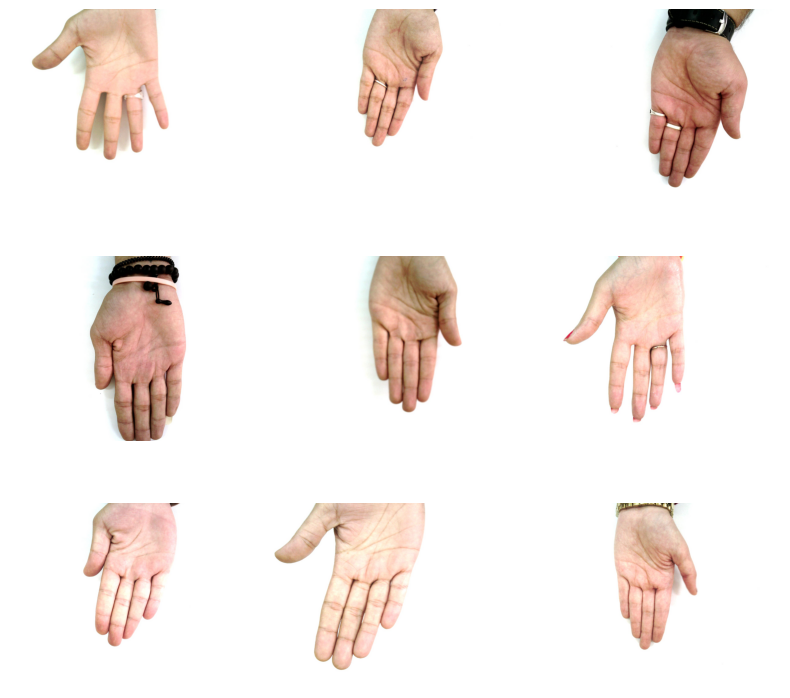

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

sample_images = random.sample(os.listdir("./split_palm_dataset/train"), 9)

plt.figure(figsize=(8,8))

for i, img_name in enumerate(sample_images):
    plt.subplot(3,3,i+1)
    img = Image.open(os.path.join("./split_palm_dataset/train", img_name))
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

**BLUR DETECTION**

In [ ]:
def blur_score(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    score = cv2.Laplacian(gray, cv2.CV_64F).var()

    return score

In [ ]:
train_folder = "./split_palm_dataset/train"

scores = []

for img in os.listdir(train_folder):
    path = os.path.join(train_folder, img)
    score = blur_score(path)

    scores.append([img, score])

blur_df = pd.DataFrame(scores, columns=["Image", "Blur Score"])

In [ ]:
blur_df.head()

,Image,Blur Score
0,Hand_0002927.jpg,10.118712
1,Hand_0004837.jpg,52.513158
2,Hand_0008077.jpg,14.050861
3,Hand_0000321.jpg,38.930820
4,Hand_0002818.jpg,14.344158


In [ ]:
blur_df["Blur Score"].describe()

,Blur Score
count,3777.000000
mean,27.893947
std,23.087021
min,2.712107
25%,11.936790
50%,21.361936
75%,36.447833
max,186.822645


In [ ]:
blur_df.sort_values("Blur Score",).head(10)



,Image,Blur Score
1114,Hand_0001791.jpg,2.712107
1804,Hand_0003173.jpg,2.819701
1007,Hand_0003171.jpg,2.914503
2384,Hand_0000618.jpg,2.942399
3193,Hand_0001765.jpg,3.026389
3526,Hand_0008695.jpg,3.179675
942,Hand_0001768.jpg,3.296200
5,Hand_0003174.jpg,3.354157
2888,Hand_0000439.jpg,3.414524
3533,Hand_0001770.jpg,3.425349


In [ ]:
pip install mediapipe opencv-python matplotlib

In [3]:
!wget -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

--2026-07-08 17:27:05--  https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.157.207, 142.251.8.207, 142.251.170.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.157.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7819105 (7.5M) [application/octet-stream]
Saving to: ‘hand_landmarker.task’

hand_landmarker.tas 100%[===================>]   7.46M  5.58MB/s    in 1.3s    

2026-07-08 17:27:08 (5.58 MB/s) - ‘hand_landmarker.task’ saved [7819105/7819105]



In [4]:
!pip install mediapipe opencv-python matplotlib ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 13.7 MB/s eta 0:00:00


In [5]:
!wget -O hand_landmarker.task \
https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

--2026-07-08 17:27:34--  https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.157.207, 142.251.8.207, 142.251.170.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.157.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7819105 (7.5M) [application/octet-stream]
Saving to: ‘hand_landmarker.task’

hand_landmarker.tas 100%[===================>]   7.46M  5.99MB/s    in 1.2s    

2026-07-08 17:27:36 (5.99 MB/s) - ‘hand_landmarker.task’ saved [7819105/7819105]



In [6]:
import mediapipe as mp

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1
)

detector = HandLandmarker.create_from_options(options)

In [18]:
from google.colab import files
import cv2
import numpy as np

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=img_rgb
)

Saving handy hand.jpg to handy hand (1).jpg


In [19]:
result = detector.detect(mp_image)

if len(result.hand_landmarks) > 0:
    confidence = result.handedness[0][0].score

    print(f"✅ Hand Detected")
    print(f"Confidence: {confidence:.2%}")
else:
    print("❌ No Hand Detected")


✅ Hand Detected
Confidence: 88.39%


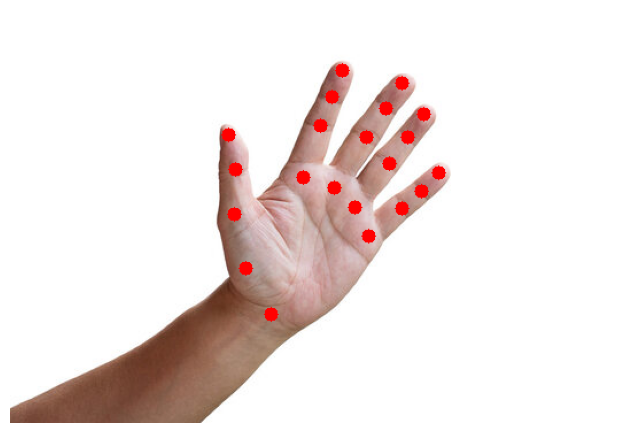

In [20]:
import matplotlib.pyplot as plt

output = img_rgb.copy()

h, w, _ = output.shape

for landmark in result.hand_landmarks[0]:

    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv2.circle(output, (x, y), 6, (255,0,0), -1)

plt.figure(figsize=(8,8))
plt.imshow(output)
plt.axis("off")
plt.show()